# Clustering by Perspectives

In [ ]:
# Remember: library imports are ALWAYS at the top of the script, no exceptions!
import sqlite3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from math import ceil

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import KMeans

from collections import Counter
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, estimate_bandwidth

from sklearn.base import clone
from sklearn.metrics import pairwise_distances

sns.set()

In [ ]:
## Un-comment these if you want to use ydata_profiling

# !pip install -U ydata-profiling
# from ydata_profiling import ProfileReport


## Context
The data we will be using through the pratical classes comes from a small relational database whose schema can be seen below:
![Schema](https://raw.githubusercontent.com/fpontejos/DMDM_2223/main/figures/schema.png "Relation database schema")

## Reading the Data

In [ ]:
## Allow Colab to see Google Drive files

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
## Load csv file into a dataframe
## Paste the path here
data_path = "/content/drive/MyDrive/Colab Data/datamining.csv"

df = pd.read_csv(data_path)

In [ ]:
## Load csv file into a dataframe
## Alternative location of the csv file

## data_path = "https://raw.githubusercontent.com/fpontejos/DM1_2324/main/data/datamining.csv"

## df = pd.read_csv(data_path)

### Make a copy of your original dataset

why?

In [ ]:
df_original = df.copy()

### Metadata
- *id* - The unique identifier of the customer
- *age* - The year of birht of the customer
- *income* - The income of the customer
- *frq* - Frequency: number of purchases made by the customer
- *rcn* - Recency: number of days since last customer purchase
- *mnt* - Monetary: amount of € spent by the customer in purchases
- *clothes* - Number of clothes items purchased by the customer
- *kitchen* - Number of kitchen items purchased by the customer
- *small_appliances* - Number of small_appliances items purchased by the customer
- *toys* - Number of toys items purchased by the customer
- *house_keeping* - Number of house_keeping items purchased by the customer
- *dependents* - Binary. Whether or not the customer has dependents
- *per_net_purchase* - Percentage of purchases made online
- *education* - Education level of the customer
- *status* - Marital status of the customer
- *gender* - Gender of the customer
- *description* - Last customer's recommendation description

## Preprocess the Data

Remember what we did in the previous session

In [ ]:
# Sometimes it is not obvious that a value is missing
# For example if the value is an empty string

# replace "" by nans
df.replace("", np.nan, inplace=True)

In [ ]:
# Define metric and non-metric features. Why?
non_metric_features = ["education", "status", "gender", "dependents", "description"]

## This is saying that the metric features are all the other features that are not non-metric
## Need to be careful in case not all columns are to be used as features

# metric_features = df.columns.drop(non_metric_features).to_list()

## Or you can also specify manually
metric_features = ['age',
 'income',
 'frq',
 'rcn',
 'mnt',
 'clothes',
 'kitchen',
 'small_appliances',
 'toys',
 'house_keeping',
 'per_net_purchase']

### Fill missing values (Data imputation)

How can we fill missing values?


#### Using measures of central tendency

In [ ]:
# Creating a copy to apply central tendency measures imputation
df_central = df.copy()

In [ ]:
# count of missing values
df_central.isna().sum()

Unnamed: 0            0
age                   0
income               46
frq                   0
rcn                   0
mnt                   0
clothes               0
kitchen               0
small_appliances      0
toys                  0
house_keeping         0
dependents          282
per_net_purchase      0
gender                0
education            47
status              177
description           0
dtype: int64

In [ ]:
medians = df_central[metric_features].median()
medians

age                  1966.0
income              70030.5
frq                    17.0
rcn                    53.0
mnt                   383.0
clothes                51.0
kitchen                 4.0
small_appliances       28.0
toys                    4.0
house_keeping           4.0
per_net_purchase       45.0
dtype: float64

In [ ]:
modes = df_central[non_metric_features].mode().loc[0]
modes

education      Graduation
status            Married
gender                  M
dependents            1.0
description      OK nice!
Name: 0, dtype: object

In [ ]:
## Fill NaNs using medians and modes

df_central.fillna(medians, inplace=True)
df_central.fillna(modes, inplace=True)

In [ ]:
df_central.isna().sum()  # checking how many NaNs we still have

Unnamed: 0          0
age                 0
income              0
frq                 0
rcn                 0
mnt                 0
clothes             0
kitchen             0
small_appliances    0
toys                0
house_keeping       0
dependents          0
per_net_purchase    0
gender              0
education           0
status              0
description         0
dtype: int64

In [ ]:
df = df_central.copy()

### Outlier removal

In [ ]:
def remove_outliers(df, filters):

  df_2 = df[filters]
  print('Percentage of data kept after removing outliers:', 100*(np.round(df_2.shape[0] / df.shape[0], 4)))

  return df_2



In [ ]:
# This may vary from session to session, and is prone to varying interpretations.
# A simple example is provided below:

manual_filters = (
    (df['house_keeping']<=50)
    &
    (df['kitchen']<=40)
    &
    (df['toys']<=35)
    &
    (df['education']!='OldSchool')
)

df_1 = remove_outliers(df, manual_filters)

Percentage of data kept after removing outliers: 97.99


In [ ]:
# Get the manual filtering version
df = df_1.copy()

In [ ]:
# How can we avoid having as many extreme values in 'rcn'?
print((df['rcn']>100).value_counts())

rcn_t = df['rcn'].copy()
rcn_t.loc[rcn_t>100] = 100

df['rcn'] = rcn_t

False    8437
True      380
Name: rcn, dtype: int64


#### What about non-metric features?

In [ ]:
# Let's also remove status=Whatever
df.loc[df['status'] == 'Whatever', 'status'] = df['status'].mode()[0]


### Feature Engineering and Feature Selection

In [ ]:
df['birth_year'] = df['age']
df['age'] = datetime.now().year - df['birth_year']

df['spent_online'] = (df['per_net_purchase'] / 100) * df['mnt']

#### Redundancy


In [ ]:
# Select variables according to their correlations
# df.drop(columns=['birth_year', 'age', 'mnt'], inplace=True)
unused_feats =['birth_year', 'age', 'mnt']

In [ ]:
# Updating metric_features
metric_features.append("spent_online")
metric_features.remove("mnt")
metric_features.remove("age")

In [ ]:
metric_features

['income',
 'frq',
 'rcn',
 'clothes',
 'kitchen',
 'small_appliances',
 'toys',
 'house_keeping',
 'per_net_purchase',
 'spent_online']

#### Relevancy
Selecting variables based on the relevancy of each one to the task. Example: remove uncorrelated variables with the target, stepwise regression, use variables for product clustering, use variables for socio-demographic clustering, ...

Variables that aren't correlated with any other variable are often also not relevant. In this case we will not focus on this a lot since we don't have a defined task yet.

### Data Normalization

#### Standard Scaling

In [ ]:
df_standard = df.copy()

In [ ]:
scaler = StandardScaler()
scaled_feat = scaler.fit_transform(df_standard[metric_features])
df_standard[metric_features] = scaled_feat


In [ ]:
df = df_standard.copy()

### One-hot encoding

In [ ]:
df_ohc = df.copy()

In [ ]:
def get_ohc_df(df, feats):
  # Use OneHotEncoder to encode the categorical features.
  # Get feature names and create a DataFrame
  # with the one-hot encoded categorical features (pass feature names)

  ohc = OneHotEncoder(sparse_output=False, drop="first")
  ohc_feat = ohc.fit_transform(df[feats])
  ohc_feat_names = ohc.get_feature_names_out()
  ohc_df = pd.DataFrame(ohc_feat, index=df.index, columns=ohc_feat_names)

  # Reassigning df to contain ohc variables
  df_ohc = pd.concat([df, ohc_df], axis=1)

  ## Return the df with the one-hot encoded features
  ## Also return the OneHotEncoder model (ohc)
  return df_ohc, ohc

df_ohc, ohc = get_ohc_df(df, non_metric_features)


In [ ]:
oh_features = ohc.get_feature_names_out().tolist()
oh_features

['education_2nd Cycle',
 'education_Graduation',
 'education_Master',
 'education_PhD',
 'status_Married',
 'status_Single',
 'status_Together',
 'status_Widow',
 'gender_M',
 'dependents_1.0',
 'description_Kind of OK',
 'description_Meh...',
 'description_OK nice!',
 'description_Take my money!!']

In [ ]:
df_ohc.columns

Index(['Unnamed: 0', 'income', 'frq', 'rcn', 'clothes', 'kitchen',
       'small_appliances', 'toys', 'house_keeping', 'dependents',
       'per_net_purchase', 'gender', 'education', 'status', 'description',
       'spent_online', 'education_2nd Cycle', 'education_Graduation',
       'education_Master', 'education_PhD', 'status_Married', 'status_Single',
       'status_Together', 'status_Widow', 'gender_M', 'dependents_1.0',
       'description_Kind of OK', 'description_Meh...', 'description_OK nice!',
       'description_Take my money!!'],
      dtype='object')

In [ ]:
df = df_ohc.copy()

## Remove noise rows with DBSCAN


In [ ]:
def split_noise_rows(df, feats, dbs_model):
  ## Splits the dataframe into noise and non-noise
  dbscan_labels = dbs_model.fit_predict(df[feats])

  df_concat = pd.concat([df,
                            pd.Series(dbscan_labels,
                                      name='dbscan_labels',
                                      index=df.index)], axis=1)

  df_noise = df_concat[df_concat['dbscan_labels']==-1].copy()
  df_nonoise = df_concat[df_concat['dbscan_labels']==0].copy()


  return df_noise, df_nonoise, df_concat

In [ ]:
## Refer to previous notebook for how to tune DBSCAN
## Based on the hyperparameters we found

dbscan = DBSCAN(eps=1.9, min_samples=20, n_jobs=4)

df_noise, df_nonoise, df_combined_noise = split_noise_rows(df, metric_features, dbscan)

In [ ]:
## Rename df_nonoise dataframe to df for simplicity
## Remember the df_combined_noise dataframe has both noise and non noise rows

print(df_combined_noise.shape)
print(df_nonoise.shape)
print(df_noise.shape)

df = df_nonoise.copy()



(8817, 31)
(8715, 31)
(102, 31)


## Clustering by Perspectives

In [ ]:
## Split variables into perspectives
## This is an example; requires critical thinking and some domain knowledge

## Demographic / Behaviour
demographic_features = [
    'income',
    'frq',
    'per_net_purchase',
    'spent_online'
]

## Preferences
preference_features = [
    'clothes',
    'kitchen',
    'small_appliances',
    'toys',
    'house_keeping',
]
unused_feats= []

df_dem = df[demographic_features].copy()
df_prf = df[preference_features].copy()

### Testing different clustering solutions

In [ ]:
# Set up the clusterers
kmeans = KMeans(
    init='k-means++',
    n_init=20,
    random_state=42
)

hierarchical = AgglomerativeClustering(
    metric='euclidean'
)


In [ ]:
## Some functions we need
def get_ss(df):
    """Computes the sum of squares for all variables given a dataset
    """
    ss = np.sum(df.var() * (df.count() - 1))
    return ss  # return sum of sum of squares of each df variable

def r2(df, labels):
    sst = get_ss(df)
    ssw = np.sum(df.groupby(labels).apply(get_ss))
    return 1 - ssw/sst

def get_r2_scores(df, clusterer, min_k=2, max_k=10):
    """
    Loop over different values of k. To be used with sklearn clusterers.
    """
    r2_clust = {}
    for n in range(min_k, max_k):
        clust = clone(clusterer).set_params(n_clusters=n)
        labels = clust.fit_predict(df)
        r2_clust[n] = r2(df, labels)
    return r2_clust


In [ ]:
def get_r2_df(df, feats, kmeans_model, hierar_model):
  # Obtaining the R² scores for each cluster solution

  r2_scores = {}
  r2_scores['kmeans'] = get_r2_scores(df[feats], kmeans_model)

  for linkage in ['complete', 'average', 'single', 'ward']:
      r2_scores[linkage] = get_r2_scores(
          df[feats], hierar_model.set_params(linkage=linkage)
      )

  return pd.DataFrame(r2_scores)

In [ ]:
def plot_r2_scores(r2_scores,
                   plot_title="Demographic Variables:\nR² plot for various clustering methods\n",
                   legend_title="Cluster methods"):
  # Visualizing the R² scores for each cluster solution on demographic variables
  pd.DataFrame(r2_scores).plot.line(figsize=(10,7))

  plt.title(plot_title, fontsize=21)
  plt.legend(title=legend_title, title_fontsize=11)
  plt.xlabel("Number of clusters", fontsize=13)
  plt.ylabel("R² metric", fontsize=13)
  plt.show()

#### Finding the optimal clusterer on demographic variables

In [ ]:
## The get_r2_df function takes a few minutes to execute

demog_r2_scores = get_r2_df(df, demographic_features, kmeans, hierarchical)
demog_r2_scores

,kmeans,complete,average,single,ward
2,0.571844,0.095809,0.064693,0.001041,0.544738
3,0.679538,0.582479,0.582650,0.001704,0.655959
4,0.756804,0.671330,0.585952,0.002164,0.711623
5,0.789277,0.700576,0.586480,0.003354,0.758156
6,0.819699,0.748638,0.651671,0.004125,0.782667
7,0.839187,0.777335,0.743790,0.004540,0.805099
8,0.854611,0.796595,0.744352,0.004743,0.823297
9,0.866556,0.828341,0.782224,0.005648,0.838379


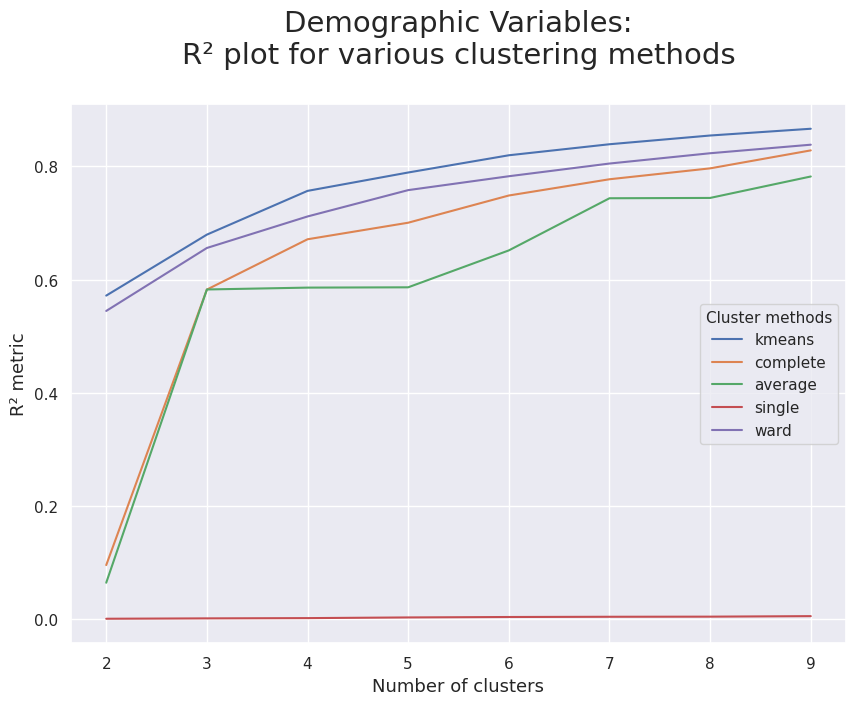

In [ ]:
plot_r2_scores(demog_r2_scores)

### Repeat for preference variables

In [ ]:
# Set up the clusterers
kmeans = KMeans(
    init='k-means++',
    n_init=20,
    random_state=42
)

hierarchical = AgglomerativeClustering(
    metric='euclidean'
)

## The get_r2_df function takes a few minutes to execute

pref_r2_scores = get_r2_df(df, preference_features, kmeans, hierarchical)
pref_r2_scores

,kmeans,complete,average,single,ward
2,0.402007,0.125904,0.071255,0.000440,0.343646
3,0.559972,0.290483,0.071662,0.001077,0.503362
4,0.617078,0.310330,0.308910,0.002130,0.565834
5,0.661973,0.519110,0.318081,0.002687,0.608999
6,0.694434,0.542480,0.351043,0.003337,0.639975
7,0.720244,0.559597,0.368885,0.005690,0.667257
8,0.740480,0.604875,0.369087,0.005944,0.689143
9,0.757640,0.612478,0.380622,0.006427,0.708878


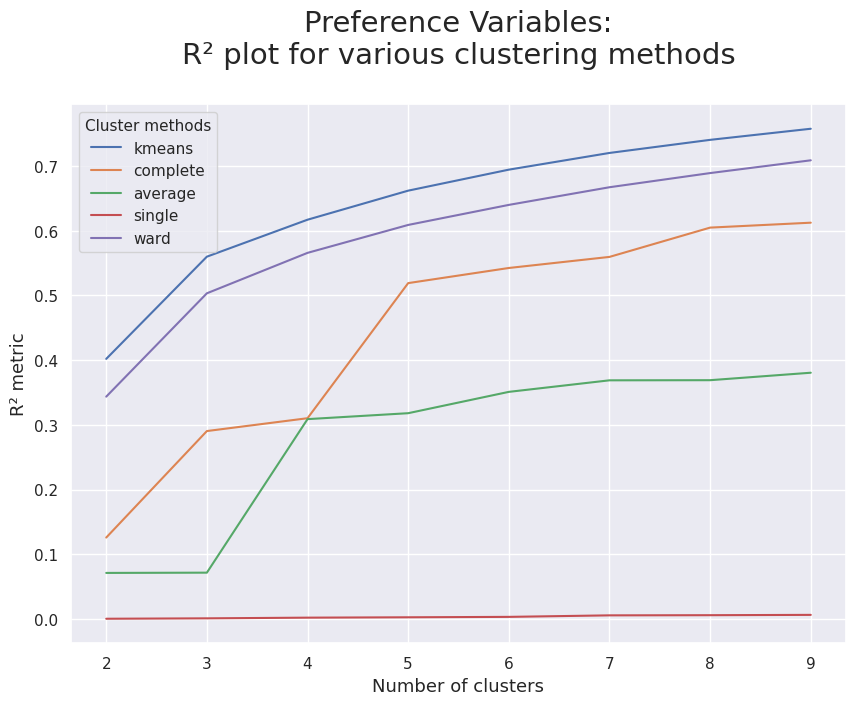

In [ ]:
plot_r2_scores(pref_r2_scores,
               plot_title="Preference Variables:\nR² plot for various clustering methods\n",
               )


### Merging Clusters

How can we merge different cluster solutions?

In [ ]:
perspective_1 = 'pref_labels'
perspective_2 = 'demog_labels'

In [ ]:
# Applying the right clustering (algorithm and number of clusters) for each perspective

kmeans_pref = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=20,
    random_state=42
)
pref_labels = kmeans_pref.fit_predict(df_prf)

df[perspective_1] = pref_labels


In [ ]:
# Applying the right clustering (algorithm and number of clusters) for each perspective

kmeans_dem = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=20,
    random_state=42
)
demog_labels = kmeans_dem.fit_predict(df_dem)

df[perspective_2] = demog_labels

In [ ]:
# Count label frequencies (contigency table)

def make_contingency_table(df, label1, label2):
  df_ = df.groupby([label1, label2])\
            .size()\
            .to_frame()\
            .reset_index()\
            .pivot(index=label2, columns=label1)
  df_.columns = df_.columns.droplevel()
  return df_



In [ ]:
make_contingency_table(df, perspective_1, perspective_2)


pref_labels,0,1,2
demog_labels,,,
0,1336,639,207
1,707,247,43
2,388,1233,291
3,1153,1458,1013


#### Manual merging: Merge lowest frequency clusters into closest clusters


The manual merging function below works by looking for the cluster (target) that is closest to the specified cluster (source) in `to_merge`.  Once a cluster has become a target, it will not be considered as a source even if it is listed in `to_merge`.

In [ ]:
def manual_merge(to_merge, df, feats, label1, label2):
  """
  Merges using list of clusters given.
  The function works by looking for the cluster (target)
  that is closest to the specified cluster (source) in `to_merge`.
  Once a cluster has become a target, it will not be considered
  as a source even if it is listed in `to_merge`.

  to_merge              : list of indices of contingency table
  df                    : DataFrame
  feats                 : list of features
  label1                : name of label (contingency table rows)
  label2                : name of label (contingency table cols)
  """
  df_centroids = df.groupby([label1, label2])\
      [feats].mean()

  # Computing the euclidean distance matrix between the centroids
  euclidean = pairwise_distances(df_centroids)
  df_dists = pd.DataFrame(
      euclidean, columns=df_centroids.index, index=df_centroids.index
  )

  # Merging each low frequency clustering (source) to the closest cluster (target)

  source_target = {}
  for clus in to_merge:
      if clus not in source_target.values():
          source_target[clus] = df_dists.loc[clus].sort_values().index[1]

  df_ = df.copy()

  # Changing the labels based on source_target
  for source, target in source_target.items():
      mask = (df_[label1]==source[0]) & (df_[label2]==source[1])
      df_.loc[mask, label1] = target[0]
      df_.loc[mask, label2] = target[1]

  return df_



In [ ]:
# Clusters with low frequency to be merged:
# (row, col)
to_merge = [(1,2), (1,1), (0,2), (2,2) ]

# Merge the low-frequency clusters
df_manual = manual_merge(to_merge, df, metric_features, perspective_2, perspective_1)


In [ ]:
df_manual.head()

,Unnamed: 0,income,frq,rcn,clothes,kitchen,small_appliances,toys,house_keeping,dependents,...,status_Widow,gender_M,dependents_1.0,description_Kind of OK,description_Meh...,description_OK nice!,description_Take my money!!,dbscan_labels,pref_labels,demog_labels
0,0,0.743162,1.191605,0.457819,-0.617023,-0.243065,1.216847,0.495837,-0.499274,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0,1,2
1,1,1.559488,1.100011,-1.535723,0.166160,-0.790228,0.740464,-0.374374,-0.631907,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,1,2
2,2,-1.548542,-0.823463,0.557496,-0.834573,1.672006,-0.371096,-0.809480,2.286023,1.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0,2,3
3,3,0.845528,0.550447,-1.402820,0.383710,0.440889,-0.768082,-0.084304,-0.234007,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0,0,0
4,4,0.782435,1.008417,-0.871209,0.340200,-0.243065,-0.053508,-0.374374,-0.366640,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0,0,1


In [ ]:
# Count NEW label frequencies (after using manual_merge function)

make_contingency_table(df_manual, perspective_1, perspective_2)


pref_labels,0,1,2
demog_labels,,,
0,1336.0,639.0,NaN
1,707.0,290.0,NaN
2,388.0,1233.0,498.0
3,1153.0,1458.0,1013.0


In [ ]:
## Reminder of original

make_contingency_table(df, perspective_1, perspective_2)


pref_labels,0,1,2
demog_labels,,,
0,1336,639,207
1,707,247,43
2,388,1233,291
3,1153,1458,1013


In [ ]:
def get_mean_bylabel(df, feats, label_name):
  # Characterizing the clusters
  return df[feats+[label_name]].groupby(label_name).mean()


In [ ]:
# Centroids of the concatenated cluster labels
df_centroids = df_manual.groupby([perspective_1, perspective_2])[metric_features].mean()
df_centroids

income       frq       rcn   clothes   kitchen  \
pref_labels demog_labels                                                     
0           0             0.140280 -0.080496 -0.075931  1.052776 -0.576134   
            1             0.693508  1.131881 -0.045360  1.099258 -0.601391   
            2             1.129881  1.207185  0.003192  0.738408 -0.524402   
            3            -0.621136 -0.884314  0.057295  0.951003 -0.603964   
1           0             0.203474 -0.114649 -0.093395 -0.245723 -0.052970   
            1             0.925596  1.264880 -0.032661 -0.282295  0.118252   
            2             1.225127  1.217530 -0.084086 -0.468884 -0.080535   
            3            -0.938724 -0.866872  0.115945 -0.460022 -0.060958   
2           2             0.788771  0.457381 -0.048039 -0.998829  1.203402   
            3            -1.328229 -0.913881  0.091910 -1.432161  1.541292   

                          small_appliances      toys  house_keeping  \
pref_labels demog_labels                                              
0           0                    -0.923965 -0.592796      -0.569859   
            1                    -0.958321 -0.621980      -0.603579   
            2                    -0.464818 -0.502588      -0.503376   
            3                    -0.695984 -0.606959      -0.601078   
1           0                     0.465742  0.012613       0.017145   
            1                     0.345395  0.083237       0.097118   
            2                     0.950322 -0.029960      -0.051247   
            3                     0.912056 -0.049288      -0.013862   
2           2                     0.035296  1.102190       0.812410   
            3                     0.021500  1.500632       1.465216   

                          per_net_purchase  spent_online  
pref_labels demog_labels                                  
0           0                     0.093666      0.164015  
            1                     0.205066      2.073131  
            2                    -1.291168      0.466297  
            3                     0.654463     -0.763638  
1           0                    -0.250912      0.051536  
            1                    -0.114181      1.982429  
            2                    -1.465394      0.288564  
            3                     0.830015     -0.789210  
2           2                    -0.982560      0.078877  
            3                     0.771821     -0.857517

In [ ]:
## Map combinations of the two labels to their merged cluster label
## For example:
## pref_labels=1, demog_labels=2 => merged_label=6

def merge_mapper(df, label1, label2, feats, merged_label):
  df_ = df.copy()

  # Centroids of the concatenated cluster labels
  df_centroids = df_.groupby([label1, label2])[feats].mean()
  df_centroids[merged_label] = np.arange(df_centroids.shape[0])

  cluster_mapper = df_centroids[merged_label].to_dict()

  # Mapping the clusters on the centroids to the observations
  df_[merged_label] = df_.apply(
      lambda row: cluster_mapper[
          (row[label1], row[label2])
      ], axis=1
  )

  return df_, df_centroids


In [ ]:
df_manual_merged, df_manual_centroids = merge_mapper(df,
                                                     perspective_1, perspective_2,
                                                     metric_features,
                                                     'manual_merged_labels')

In [ ]:
df_manual_merged.head()

,Unnamed: 0,income,frq,rcn,clothes,kitchen,small_appliances,toys,house_keeping,dependents,...,gender_M,dependents_1.0,description_Kind of OK,description_Meh...,description_OK nice!,description_Take my money!!,dbscan_labels,pref_labels,demog_labels,manual_merged_labels
0,0,0.743162,1.191605,0.457819,-0.617023,-0.243065,1.216847,0.495837,-0.499274,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0,1,2,6
1,1,1.559488,1.100011,-1.535723,0.166160,-0.790228,0.740464,-0.374374,-0.631907,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0,1,2,6
2,2,-1.548542,-0.823463,0.557496,-0.834573,1.672006,-0.371096,-0.809480,2.286023,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0,2,3,11
3,3,0.845528,0.550447,-1.402820,0.383710,0.440889,-0.768082,-0.084304,-0.234007,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0,0,0,0
4,4,0.782435,1.008417,-0.871209,0.340200,-0.243065,-0.053508,-0.374374,-0.366640,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0,0,1,1


In [ ]:
## showing only the mapping from (label1, label1) => merged_label
df_manual_centroids[['manual_merged_labels']]


manual_merged_labels
pref_labels demog_labels                      
0           0                                0
            1                                1
            2                                2
            3                                3
1           0                                4
            1                                5
            2                                6
            3                                7
2           0                                8
            1                                9
            2                               10
            3                               11

#### Merge using Hierarchical Clustering

In [ ]:
# Centroids of the concatenated cluster labels
df_hc_centroids = df.groupby([perspective_1, perspective_2])[metric_features].mean()
df_hc_centroids

income       frq       rcn   clothes   kitchen  \
pref_labels demog_labels                                                     
0           0             0.140280 -0.080496 -0.075931  1.052776 -0.576134   
            1             0.693508  1.131881 -0.045360  1.099258 -0.601391   
            2             1.129881  1.207185  0.003192  0.738408 -0.524402   
            3            -0.621136 -0.884314  0.057295  0.951003 -0.603964   
1           0             0.203474 -0.114649 -0.093395 -0.245723 -0.052970   
            1             0.935409  1.306561 -0.022407 -0.206583 -0.048124   
            2             1.225127  1.217530 -0.084086 -0.468884 -0.080535   
            3            -0.938724 -0.866872  0.115945 -0.460022 -0.060958   
2           0             0.223129 -0.240270 -0.131415 -0.858325  1.193569   
            1             0.869229  1.025457 -0.091564 -0.717197  1.073944   
            2             1.191136  0.953649  0.011270 -1.098774  1.210396   
            3            -1.328229 -0.913881  0.091910 -1.432161  1.541292   

                          small_appliances      toys  house_keeping  \
pref_labels demog_labels                                              
0           0                    -0.923965 -0.592796      -0.569859   
            1                    -0.958321 -0.621980      -0.603579   
            2                    -0.464818 -0.502588      -0.503376   
            3                    -0.695984 -0.606959      -0.601078   
1           0                     0.465742  0.012613       0.017145   
            1                     0.457913 -0.040265      -0.048750   
            2                     0.950322 -0.029960      -0.051247   
            3                     0.912056 -0.049288      -0.013862   
2           0                    -0.261014  1.127126       0.866784   
            1                    -0.300932  0.792654       0.935015   
            2                     0.246073  1.084451       0.773731   
            3                     0.021500  1.500632       1.465216   

                          per_net_purchase  spent_online  
pref_labels demog_labels                                  
0           0                     0.093666      0.164015  
            1                     0.205066      2.073131  
            2                    -1.291168      0.466297  
            3                     0.654463     -0.763638  
1           0                    -0.250912      0.051536  
            1                    -0.101336      2.043056  
            2                    -1.465394      0.288564  
            3                     0.830015     -0.789210  
2           0                    -0.359403     -0.077162  
            1                    -0.187964      1.634177  
            2                    -1.425837      0.189875  
            3                     0.771821     -0.857517

In [ ]:
# Using Hierarchical clustering to merge the concatenated cluster centroids
hclust = AgglomerativeClustering(
    linkage='ward',
    metric='euclidean',
    distance_threshold=0,
    n_clusters=None
)
hclust_labels = hclust.fit_predict(df_centroids)

In [ ]:
#####
## Same function as in lab03

def plot_dendrogram(df, feats,
                    linkage='ward', distance='euclidean',
                    y_threshold = 75):

  # setting distance_threshold=0 and n_clusters=None ensures we compute the full tree
  hclust = AgglomerativeClustering(linkage=linkage,
                                  metric=distance,
                                  distance_threshold=0,
                                  n_clusters=None)

  hclust.fit_predict(df[feats])


  # Adapted from:
  # https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html#sphx-glr-auto-examples-cluster-plot-agglomerative-dendrogram-py

  # create the counts of samples under each node (number of points being merged)
  counts = np.zeros(hclust.children_.shape[0])
  n_samples = len(hclust.labels_)

  # hclust.children_ contains the observation ids that are being merged together
  # At the i-th iteration, children[i][0] and children[i][1] are merged to form node n_samples + i
  for i, merge in enumerate(hclust.children_):
      # track the number of observations in the current cluster being formed
      current_count = 0
      for child_idx in merge:
          if child_idx < n_samples:
              # If this is True, then we are merging an observation
              current_count += 1  # leaf node
          else:
              # Otherwise, we are merging a previously formed cluster
              current_count += counts[child_idx - n_samples]
      counts[i] = current_count



  ## Create linkage matrix

  # the hclust.children_ is used to indicate the two points/clusters being merged (dendrogram's u-joins)
  # the hclust.distances_ indicates the distance between the two points/clusters (height of the u-joins)
  # the counts indicate the number of points being merged (dendrogram's x-axis)
  linkage_matrix = np.column_stack(
      [hclust.children_, hclust.distances_, counts]
  ).astype(float)






  # Plot the corresponding dendrogram

  sns.set()
  fig = plt.figure(figsize=(11,5))


  # The Dendrogram parameters need to be tuned
  # "dendrogram" function will plot our dendrogram
  dendrogram(linkage_matrix,
            truncate_mode='level',
            p=5,
            color_threshold=y_threshold,
            above_threshold_color='k')




  plt.hlines(y_threshold, 0, 1000, colors="r", linestyles="dashed")
  plt.title(f'Hierarchical Clustering - {linkage.title()}\'s Dendrogram', fontsize=21)
  plt.xlabel('Number of points in node (or index of point if no parenthesis)')
  plt.ylabel(f'{distance.title()} Distance', fontsize=13)
  plt.show()



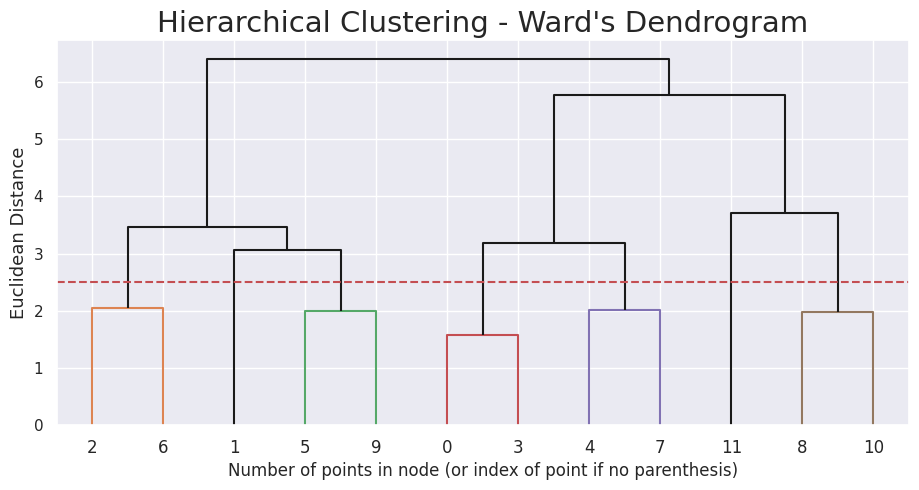

In [ ]:
# set y_threshold to a lower value to visualize where we want the dendrogram to cut
plot_dendrogram(df_hc_centroids, metric_features, y_threshold=2.5)


From the dendrogram we can see which clusters are being merged:

- 2 and 6 (orange)
- 5 and 9 (green)
- 0 and 3 (red)
- 4 and 7 (purple)
etc.

In this case, the x-labels in the dendrogram correspond to:

x: (pref, demog)

- 2: (0,2)
- 6: (1,2)
- 5: (1,1)
- 9: (2,1)
- 0: (0,0)
- 3: (0,3)
- 4: (1,0)
- 7: (1,3)



(see cell below)

In [ ]:
df_hc_centroids[[]].reset_index()


,pref_labels,demog_labels
0,0,0
1,0,1
2,0,2
3,0,3
4,1,0
5,1,1
6,1,2
7,1,3
8,2,0
9,2,1


In [ ]:
## Map combinations of the two labels to their merged cluster label

def hc_merge_mapper(df, label1, label2, feats, merged_label, n_clusters=1):
  """
  merged_label  : what to call the column that should contain the merged label
  n_clusters    : how many clusters to keep
  """
  df_ = df.copy()

  # Centroids of the concatenated cluster labels
  df_centroids = df_.groupby([label1, label2])[feats].mean()

  # Re-running the Hierarchical clustering based on the correct number of clusters
  hclust = AgglomerativeClustering(
      linkage='ward',
      metric='euclidean',
      n_clusters=n_clusters
  )
  hclust_labels = hclust.fit_predict(df_centroids)
  df_centroids[merged_label] = hclust_labels

  cluster_mapper = df_centroids[merged_label].to_dict()

  # Mapping the clusters on the centroids to the observations
  df_[merged_label] = df_.apply(
      lambda row: cluster_mapper[
          (row[label1], row[label2])
      ], axis=1
  )

  return df_, df_centroids


In [ ]:
df_hc_merged, df_hc_centroids = hc_merge_mapper(df, perspective_1, perspective_2, metric_features, 'hc_merged_labels', 7)


In [ ]:
df_hc_merged.head()

,Unnamed: 0,income,frq,rcn,clothes,kitchen,small_appliances,toys,house_keeping,dependents,...,gender_M,dependents_1.0,description_Kind of OK,description_Meh...,description_OK nice!,description_Take my money!!,dbscan_labels,pref_labels,demog_labels,hc_merged_labels
0,0,0.743162,1.191605,0.457819,-0.617023,-0.243065,1.216847,0.495837,-0.499274,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0,1,2,0
1,1,1.559488,1.100011,-1.535723,0.166160,-0.790228,0.740464,-0.374374,-0.631907,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0,1,2,0
2,2,-1.548542,-0.823463,0.557496,-0.834573,1.672006,-0.371096,-0.809480,2.286023,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0,2,3,3
3,3,0.845528,0.550447,-1.402820,0.383710,0.440889,-0.768082,-0.084304,-0.234007,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0,0,0,5
4,4,0.782435,1.008417,-0.871209,0.340200,-0.243065,-0.053508,-0.374374,-0.366640,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0,0,1,6


In [ ]:
## showing only the mapping from (label1, label2) => merged_label

df_hc_centroids[['hc_merged_labels']].reset_index()

,pref_labels,demog_labels,hc_merged_labels
0,0,0,5
1,0,1,6
2,0,2,0
3,0,3,5
4,1,0,2
5,1,1,1
6,1,2,0
7,1,3,2
8,2,0,4
9,2,1,1


Remember from the dendrogram that we merged:

- 2 and 6 (orange)
  - as 0
- 5 and 9 (green)
  - as 1
- 0 and 3 (red)
  - as 5
- 4 and 7 (purple)
  - as 2


In [ ]:
df_hc_merged['hc_merged_labels'].value_counts()

5    2489
2    2097
0    1621
3    1013
6     707
4     498
1     290
Name: hc_merged_labels, dtype: int64

In [ ]:
## Get final DF
df = df_hc_merged.copy()

## Next: Cluster Analysis and Characterization

### Questions?

### How is your project progressing?

## [OPTIONAL] Exercise

To practice your clustering skills, you can do the same exercises on a different dataset.


The Spaceship Titanic Dataset has been loaded for you in the cells below. You can find more information about this dataset from the Kaggle link.


Using this notebook as a guide, try to answer the questions that follow.


---

Addison Howard, Ashley Chow, Ryan Holbrook. (2022). Spaceship Titanic. Kaggle. https://kaggle.com/competitions/spaceship-titanic


In [ ]:
titanic_df = pd.read_csv("https://raw.githubusercontent.com/fpontejos/DM1_2324/main/data/spaceship_titanic_dataset.csv")


In [ ]:
## Keep only the useful features that you identified in the previous exercise

titanic_metric_features = []
titanic_non_metric_features = []


In [ ]:
titanic_metric_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
titanic_non_metric_features = ['HomePlanet', 'CryoSleep', 'Destination','VIP', 'Transported']


In [ ]:
## Don't forget to do the preprocessing steps you performed in the previous exercise


In [ ]:
titanic_df['Name'].replace(np.nan, "NO_NAME", inplace=True)
titanic_df['Cabin'].replace(np.nan, "NO_CABIN", inplace=True)

## Replace missing values using one of the methods shown previously
titanic_central = titanic_df.copy()

titanic_medians = titanic_central[titanic_metric_features].median()
titanic_modes = titanic_central[titanic_non_metric_features].mode().loc[0]

titanic_central.fillna(titanic_medians, inplace=True)
titanic_central.fillna(titanic_modes, inplace=True)

titanic_df = titanic_central.copy()


## Outlier treatment
## Use manual filters
titanic_manual_filters = (
    (titanic_df['RoomService']<=8000)
    &
    (titanic_df['FoodCourt']<=20000)
    &
    (titanic_df['ShoppingMall']<=7500)
    &
    (titanic_df['Spa']<=11000)
    &
    (titanic_df['VRDeck']<=12000)
)

titanic_df_1 = remove_outliers(titanic_df, titanic_manual_filters)
titanic_df = titanic_df_1.copy()

###########################
## with the titanic dataset we are only left with Age as a metric demographic feature
## for demo we will create a new feature "Monetary" based on the total spend on all services
## and use this as an additional feature

titanic_df['Monetary'] = titanic_df[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1)
titanic_metric_features.append('Monetary')

##
###########################



# Use StandardScaler to scale the data
titanic_std = titanic_df.copy()
titanic_scaler = StandardScaler()
titanic_scaled_feat = titanic_scaler.fit_transform(titanic_std[titanic_metric_features])
titanic_std[titanic_metric_features] = titanic_scaled_feat

titanic_df = titanic_std.copy()

## One-hot encode categorical features
titanic_df_ohc, titanic_ohc = get_ohc_df(titanic_df, titanic_non_metric_features)

titanic_df = titanic_df_ohc.copy()

Percentage of data kept after removing outliers: 99.41


In [ ]:
titanic_df.shape

(8642, 22)

In [ ]:
## Use DBSCAN to identify and separate noise rows
## making sure to use the appropriate hyperparameters such as eps and min_samples


In [ ]:
dbscan_titanic = DBSCAN(eps=1.3, min_samples=12, n_jobs=4)
dbscan_titanic_labels = dbscan_titanic.fit_predict(titanic_df[titanic_metric_features])
dft_noise, dft_nonoise, dft_combined_noise = split_noise_rows(titanic_df, titanic_metric_features, dbscan_titanic)


In [ ]:
dft_noise.shape, dft_nonoise.shape, dft_combined_noise.shape

((343, 23), (8299, 23), (8642, 23))

In [ ]:
## Keep no noise df

In [ ]:
titanic_df = dft_nonoise.copy()

In [ ]:
## Perform clustering using two perspectives

In [ ]:
## based on the customers' preferences
titanic_pref_feats = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
ti_pers_1 = 'pref_labels'


In [ ]:
## based on demographic + value features

titanic_demog_feats = ['Age', 'Monetary']
ti_pers_2 = 'demog_labels'

In [ ]:
## Determine appropriate K for each

In [ ]:
## Do for perspective_1

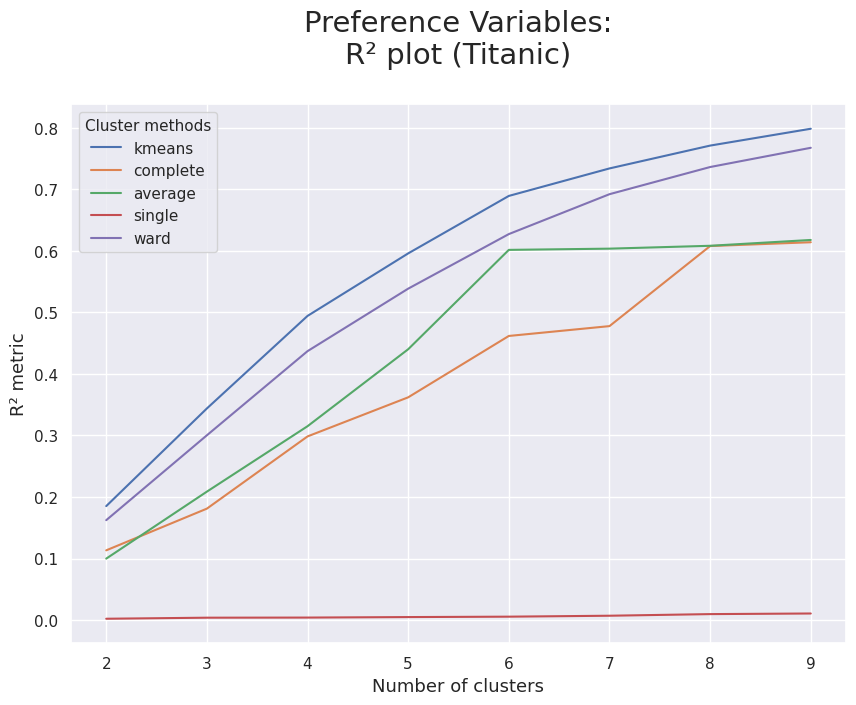

In [ ]:
# Set up the clusterers
kmeans_t = KMeans(
    init='k-means++',
    n_init=20,
    random_state=42
)

hierarchical_t = AgglomerativeClustering(
    metric='euclidean'
)

## The get_r2_df function takes a few minutes to execute

t_pref_r2_scores = get_r2_df(titanic_df, titanic_pref_feats, kmeans_t, hierarchical_t)

plot_r2_scores(t_pref_r2_scores, plot_title="Preference Variables:\nR² plot (Titanic)\n")


In [ ]:
## Repeat for perspective_2

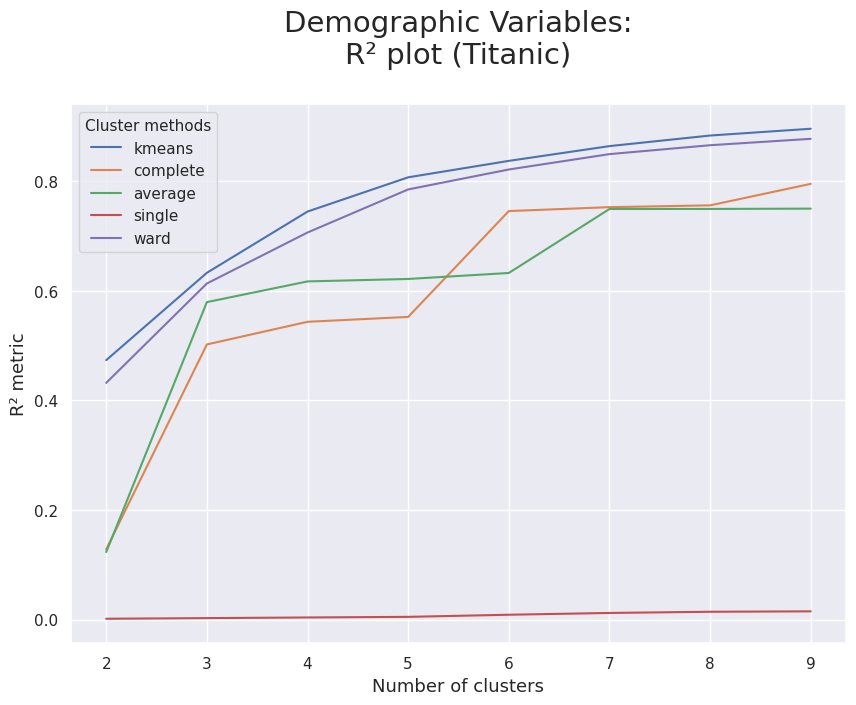

In [ ]:
# Set up the clusterers
kmeans_t = KMeans(
    init='k-means++',
    n_init=20,
    random_state=42
)

hierarchical_t = AgglomerativeClustering(
    metric='euclidean'
)

## The get_r2_df function takes a few minutes to execute

t_demog_r2_scores = get_r2_df(titanic_df, titanic_demog_feats, kmeans_t, hierarchical_t)

plot_r2_scores(t_demog_r2_scores, plot_title="Demographic Variables:\nR² plot (Titanic)\n")


In [ ]:
# Applying the right clustering (algorithm and number of clusters) for each perspective


In [ ]:
# Choosing 4 instead of 6 here because 6 results in a lot of very small clusters
ti_kmeans_pref = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=20,
    random_state=42
)

ti_pref_labels = ti_kmeans_pref.fit_predict(titanic_df[titanic_pref_feats])
titanic_df[ti_pers_1] = ti_pref_labels

################################

ti_kmeans_demog = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=20,
    random_state=42
)

ti_demog_labels = ti_kmeans_demog.fit_predict(titanic_df[titanic_demog_feats])
titanic_df[ti_pers_2] = ti_demog_labels


In [ ]:
# Inspect contingency table

In [ ]:
## small clusters?
make_contingency_table(titanic_df, ti_pers_1, ti_pers_2)

pref_labels,0,1,2,3
demog_labels,,,,
0,34,113,57,605
1,4268,300,470,24
2,1904,210,253,61


In [ ]:
## Merge the two perspectives using Manual method shown in this notebook


In [ ]:
# Clusters with low frequency to be merged:
# (row,col)
ti_to_merge = [(0,0), (0,2), (1,3), (2,3)]

# Merge the low-frequency clusters
t_df_manual = manual_merge(ti_to_merge,
                           titanic_df, titanic_metric_features,
                           ti_pers_2, ti_pers_1)


In [ ]:
make_contingency_table(t_df_manual, ti_pers_1, ti_pers_2)


pref_labels,0,1,2,3
demog_labels,,,,
0,24.0,113.0,NaN,666.0
1,4302.0,300.0,527.0,NaN
2,1904.0,210.0,253.0,NaN


In [ ]:
# Still some clusters with low frequency: (1,3) got moved to the empty cluster of (0,0):
# (row,col)

ti_to_merge = [(0,0)]

# Merge the low-frequency clusters
t_df_manual = manual_merge(ti_to_merge,
                           t_df_manual, titanic_metric_features,
                           ti_pers_2, ti_pers_1)


In [ ]:
make_contingency_table(t_df_manual, ti_pers_1, ti_pers_2)


pref_labels,0,1,2,3
demog_labels,,,,
0,NaN,113.0,NaN,666.0
1,4326.0,300.0,527.0,NaN
2,1904.0,210.0,253.0,NaN


In [ ]:
t_df_manual_merged, t_df_manual_centroids = merge_mapper(t_df_manual,
                                                     ti_pers_1, ti_pers_2,
                                                     titanic_metric_features,
                                                     'manual_merged_labels')

In [ ]:
# How many rows in each cluster?

In [ ]:
t_df_manual_merged['manual_merged_labels'].value_counts()


0    4326
1    1904
7     666
5     527
3     300
6     253
4     210
2     113
Name: manual_merged_labels, dtype: int64

In [ ]:
## Merge the two perspectives using Hierarchical clustering method shown in this notebook


In [ ]:
## Plot dendrogram for centroids

# Centroids of the concatenated cluster labels
titanic_centroids = titanic_df.groupby([ti_pers_1, ti_pers_2])[titanic_metric_features].mean()
titanic_centroids

Age  RoomService  FoodCourt  ShoppingMall  \
pref_labels demog_labels                                                   
0           0             0.148576    -0.147839   0.723599     -0.206150   
            1            -0.662819    -0.257864  -0.228757     -0.274371   
            2             1.112682    -0.224719  -0.196855     -0.264653   
1           0             0.077178     4.044192  -0.158982      0.130834   
            1            -0.414758     1.963202  -0.267449     -0.138256   
            2             1.166174     1.907421  -0.234876     -0.098123   
2           0             0.133536     0.197287   0.118616      3.670683   
            1            -0.446887    -0.142652  -0.255546      1.732757   
            2             1.118639    -0.108153  -0.243349      1.758123   
3           0             0.338302    -0.300084   1.404097     -0.265589   
            1            -0.720631    -0.315173   0.103016     -0.236084   
            2             1.911409    -0.328725   0.567671     -0.295990   

                               Spa    VRDeck  Monetary  
pref_labels demog_labels                                
0           0             0.039664  0.337960  0.504488  
            1            -0.200141 -0.183722 -0.405171  
            2            -0.182026 -0.167008 -0.362417  
1           0            -0.204526 -0.131418  0.797191  
            1            -0.211818 -0.225784  0.124948  
            2            -0.225440 -0.223245  0.134764  
2           0            -0.056901 -0.101509  0.805377  
            1            -0.237074 -0.242650 -0.021486  
            2            -0.201487 -0.211598  0.025282  
3           0             1.095987  1.041391  1.542011  
            1             1.479969  0.179646  0.567939  
            2             1.158653  0.470685  0.824697

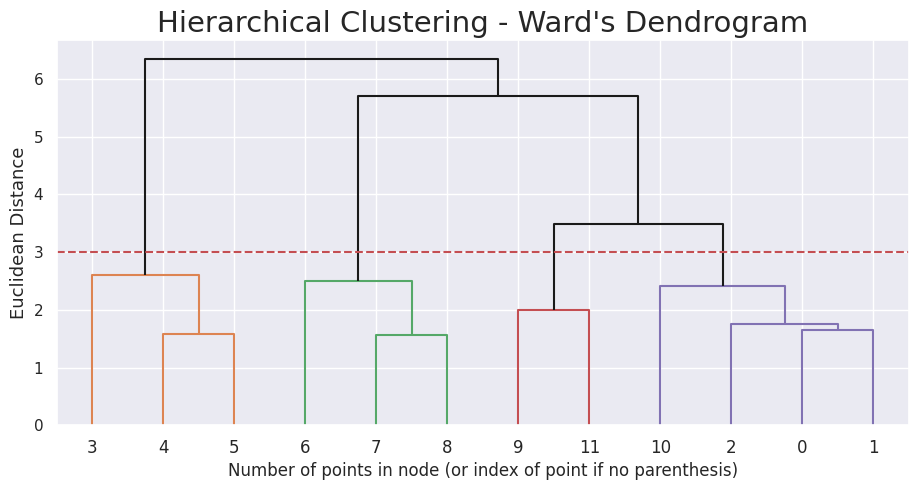

In [ ]:
plot_dendrogram(titanic_centroids, titanic_metric_features, y_threshold=3)


In [ ]:
t_df_hc_merged, t_df_hc_centroids = hc_merge_mapper(titanic_df,
                                                    ti_pers_1, ti_pers_2,
                                                    titanic_metric_features,
                                                    'hc_merged_labels', 4)


In [ ]:
t_df_hc_merged['hc_merged_labels'].value_counts()

1    6230
2     780
3     666
0     623
Name: hc_merged_labels, dtype: int64

In [ ]:
# Which one to keep?


In [ ]:
## Prefer to keep the manual merging

In [ ]:
titanic_df = t_df_manual_merged.copy()